In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/playground-series-s6e4/sample_submission.csv
/kaggle/input/competitions/playground-series-s6e4/train.csv
/kaggle/input/competitions/playground-series-s6e4/test.csv


In [2]:
train = pd.read_csv("/kaggle/input/competitions/playground-series-s6e4/train.csv")
test = pd.read_csv("/kaggle/input/competitions/playground-series-s6e4/test.csv")

In [3]:
# train.head()
train.info()
# train.dtypes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 21 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Soil_Type                630000 non-null  object 
 2   Soil_pH                  630000 non-null  float64
 3   Soil_Moisture            630000 non-null  float64
 4   Organic_Carbon           630000 non-null  float64
 5   Electrical_Conductivity  630000 non-null  float64
 6   Temperature_C            630000 non-null  float64
 7   Humidity                 630000 non-null  float64
 8   Rainfall_mm              630000 non-null  float64
 9   Sunlight_Hours           630000 non-null  float64
 10  Wind_Speed_kmh           630000 non-null  float64
 11  Crop_Type                630000 non-null  object 
 12  Crop_Growth_Stage        630000 non-null  object 
 13  Season                   630000 non-null  object 
 14  Irri

In [4]:
cat_cols = train.select_dtypes(include=["object"]).columns
num_cols = train.select_dtypes(include=["int64", "float64"]).columns

print("Numerical columns:", num_cols, len(num_cols))
print("Categorical columns", cat_cols, len(cat_cols))

Numerical columns: Index(['id', 'Soil_pH', 'Soil_Moisture', 'Organic_Carbon',
       'Electrical_Conductivity', 'Temperature_C', 'Humidity', 'Rainfall_mm',
       'Sunlight_Hours', 'Wind_Speed_kmh', 'Field_Area_hectare',
       'Previous_Irrigation_mm'],
      dtype='object') 12
Categorical columns Index(['Soil_Type', 'Crop_Type', 'Crop_Growth_Stage', 'Season',
       'Irrigation_Type', 'Water_Source', 'Mulching_Used', 'Region',
       'Irrigation_Need'],
      dtype='object') 9


In [5]:
train.isnull().sum()

id                         0
Soil_Type                  0
Soil_pH                    0
Soil_Moisture              0
Organic_Carbon             0
Electrical_Conductivity    0
Temperature_C              0
Humidity                   0
Rainfall_mm                0
Sunlight_Hours             0
Wind_Speed_kmh             0
Crop_Type                  0
Crop_Growth_Stage          0
Season                     0
Irrigation_Type            0
Water_Source               0
Field_Area_hectare         0
Mulching_Used              0
Previous_Irrigation_mm     0
Region                     0
Irrigation_Need            0
dtype: int64

In [6]:
train.duplicated().sum()

for col in cat_cols:
    print("Column", col, "===>", train[col].unique())
# train[num_cols].nunique().sort_values()

Column Soil_Type ===> ['Loamy' 'Clay' 'Sandy' 'Silt']
Column Crop_Type ===> ['Sugarcane' 'Wheat' 'Rice' 'Potato' 'Cotton' 'Maize']
Column Crop_Growth_Stage ===> ['Sowing' 'Vegetative' 'Flowering' 'Harvest']
Column Season ===> ['Zaid' 'Kharif' 'Rabi']
Column Irrigation_Type ===> ['Drip' 'Rainfed' 'Sprinkler' 'Canal']
Column Water_Source ===> ['Rainwater' 'River' 'Reservoir' 'Groundwater']
Column Mulching_Used ===> ['No' 'Yes']
Column Region ===> ['East' 'South' 'North' 'West' 'Central']
Column Irrigation_Need ===> ['Low' 'Medium' 'High']


## Numerical columns analysis

In [7]:
train[num_cols].describe()

,id,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Field_Area_hectare,Previous_Irrigation_mm
count,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000
mean,314999.500000,6.482497,37.304482,0.922858,1.744605,26.998166,61.563180,1462.207566,7.513382,10.375394,7.517745,62.318177
std,181865.479132,0.922504,16.377082,0.365808,0.952321,8.623621,19.708152,612.989738,1.999322,5.689458,4.218124,34.246939
min,0.000000,4.800000,8.000000,0.300000,0.100000,12.000000,25.000000,0.380000,4.000000,0.500000,0.300000,0.020000
25%,157499.750000,5.690000,23.340000,0.610000,0.930000,19.517500,45.390000,954.570000,5.760000,5.280000,3.880000,33.140000
50%,314999.500000,6.440000,37.750000,0.910000,1.740000,26.960000,61.650000,1467.160000,7.580000,10.480000,7.380000,61.150000
75%,472499.250000,7.270000,51.270000,1.220000,2.580000,34.540000,79.120000,2054.280000,9.250000,15.430000,11.140000,92.690000
max,629999.000000,8.200000,64.990000,1.600000,3.500000,42.000000,94.990000,2499.690000,11.000000,20.000000,15.000000,119.990000


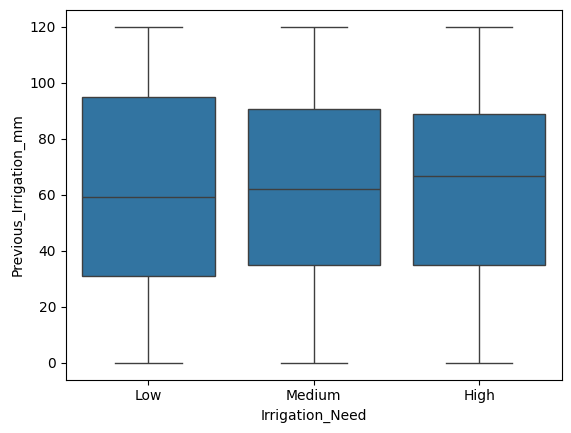

In [8]:
sns.boxplot(x=train["Irrigation_Need"], y=train["Previous_Irrigation_mm"])
plt.show()

<Axes: xlabel='Previous_Irrigation_mm', ylabel='Count'>

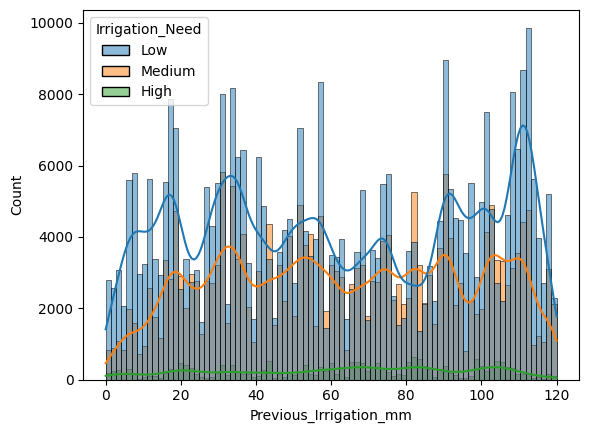

In [9]:
sns.histplot(data=train, x="Previous_Irrigation_mm", hue="Irrigation_Need", kde=True)

In [10]:
for col in num_cols:
    # print(col, "===>", train.groupby("Irrigation_Need")[col].mean())
    print(col, "===>", train.groupby("Irrigation_Need")[col].std())

id ===> Irrigation_Need
High      181960.572514
Low       181798.379921
Medium    181961.360345
Name: id, dtype: float64
Soil_pH ===> Irrigation_Need
High      0.978948
Low       0.916681
Medium    0.925763
Name: Soil_pH, dtype: float64
Soil_Moisture ===> Irrigation_Need
High       7.479613
Low       13.421279
Medium    16.624592
Name: Soil_Moisture, dtype: float64
Organic_Carbon ===> Irrigation_Need
High      0.373870
Low       0.365927
Medium    0.364882
Name: Organic_Carbon, dtype: float64
Electrical_Conductivity ===> Irrigation_Need
High      0.891465
Low       0.961384
Medium    0.942780
Name: Electrical_Conductivity, dtype: float64
Temperature_C ===> Irrigation_Need
High      5.420716
Low       8.364835
Medium    8.503269
Name: Temperature_C, dtype: float64
Humidity ===> Irrigation_Need
High      19.242509
Low       19.913072
Medium    19.413552
Name: Humidity, dtype: float64
Rainfall_mm ===> Irrigation_Need
High      800.312437
Low       584.804731
Medium    618.449689
Name: Rai

In [11]:
from scipy.stats import f_oneway

for col in num_cols:
    groups = [train[train["Irrigation_Need"] == c][col] for c in train["Irrigation_Need"].unique()]
    f_stat, p_value = f_oneway(*groups)
    status = "Significant" if p_value < 0.05 else "Insignificant"
    print(f"{col:<20} | {f_stat:<12.4f} | {p_value:<12.4e} | {status}")

id                   | 0.3929       | 6.7507e-01   | Insignificant
Soil_pH              | 158.2962     | 1.8626e-69   | Significant
Soil_Moisture        | 82555.9179   | 0.0000e+00   | Significant
Organic_Carbon       | 16.1679      | 9.5181e-08   | Significant
Electrical_Conductivity | 146.9581     | 1.5553e-64   | Significant
Temperature_C        | 22043.7591   | 0.0000e+00   | Significant
Humidity             | 172.2973     | 1.5585e-75   | Significant
Rainfall_mm          | 7241.6312    | 0.0000e+00   | Significant
Sunlight_Hours       | 8.7403       | 1.6003e-04   | Significant
Wind_Speed_kmh       | 22514.0942   | 0.0000e+00   | Significant
Field_Area_hectare   | 130.1552     | 3.0619e-57   | Significant
Previous_Irrigation_mm | 137.6441     | 1.7179e-60   | Significant


In [12]:
# for col in num_cols:
#     print(col, "===>", train[col].corr(train["Irrigation_Need"]))

In [13]:
X = train.drop(["id", "Irrigation_Need"], axis=1)

test_id = test["id"]
X_ = test.drop(["id"], axis=1)
y = train["Irrigation_Need"]


In [14]:
combined = pd.concat([X, X_])

In [15]:
cat_columns = combined.select_dtypes(include=["object"]).columns
cat_columns

Index(['Soil_Type', 'Crop_Type', 'Crop_Growth_Stage', 'Season',
       'Irrigation_Type', 'Water_Source', 'Mulching_Used', 'Region'],
      dtype='object')

In [16]:
combined = pd.get_dummies(combined, columns=cat_columns)

In [17]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y)

In [18]:
X = combined.iloc[:len(y), :]
test = combined.iloc[len(y):, :]

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [20]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [21]:
from sklearn.metrics import accuracy_score, classification_report

val_preds = model.predict(X_val)
# print(accuracy_score(y_val, val_preds))
print(classification_report(y_val, val_preds))

              precision    recall  f1-score   support

           0       0.98      0.88      0.93      4249
           1       0.99      1.00      0.99     73737
           2       0.98      0.98      0.98     48014

    accuracy                           0.98    126000
   macro avg       0.98      0.95      0.97    126000
weighted avg       0.98      0.98      0.98    126000



In [22]:
test_preds = model.predict(test)

In [23]:
test_preds = le.inverse_transform(test_preds)

In [24]:
submit = pd.DataFrame({"id": test_id, "Irrigation_Need": test_preds})
submit.to_csv("submission.csv", index=False)